In [8]:
import json
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.lines as mlines

from src.gait_analysis.data_cleaning.data_smoothing import smooth_pose_data
from src.gait_analysis.parameter_calculation.visualize import visualize_gait_phase
from src.gait_analysis.parameter_calculation.kinematic_parameters.angles import (
    calculate_kinematic_angles,
)
from src.gait_analysis.parameter_calculation.biomecanical_parameters.ground_contact_time import (
    calculate_gct,
)
from src.gait_analysis.parameter_calculation.biomecanical_parameters.ground_contact_time import (
    calculate_flight_times,
)
from src.gait_analysis.parameter_calculation.kinematic_parameters.step_parameters import (
    calculate_step_metrics,
)

In [9]:
model_id = "000332"
video_key = "v1"  # v1 or v2
setting = "outdoor"  # "treadmill" or "outdoor"

fps = "RES1080_FPS60_LENlinear" # "RES1080_FPS240_LENwide" or "RES1080_FPS60_LENlinear"

overlay_path = f"../data/output/tuned_yolo_overlays/{model_id}/{setting}/{fps}/{video_key}_overlay.mp4"
pose_model_output_path = f"../data/output/tuned_yolo/{model_id}/{setting}/{fps}/{video_key}.json"

In [10]:
cap = cv2.VideoCapture(overlay_path)
FPS = cap.get(cv2.CAP_PROP_FPS)

cap.get(cv2.CAP_PROP_FRAME_WIDTH) ,  cap.get(cv2.CAP_PROP_FRAME_HEIGHT), cap.get(cv2.CAP_PROP_FRAME_COUNT)
cap.release()

In [11]:
with open(os.path.join(pose_model_output_path), "r") as f:
    pose_model_output = json.load(f)

connections = pose_model_output["connections"]
pose_data = pose_model_output["pose_data"]

anchors = ["heel", "big_toe", "knee"]

In [12]:
keypoints = list(set([x for xs in connections for x in xs]))
keys_to_exclude = {"raw_keypoints"}

smooth_data = smooth_pose_data(
    pose_data=pose_data,
    keypoints=keypoints,
    anchors=anchors,
    keys_to_exclude=keys_to_exclude,
    fps=FPS,
    cutoff=4.0,
)

# 1. KINEMATIC PARAMETERS - ANGLES

* **Joint Angles (Hip, Knee, Ankle)**
  These angles are derived by first calculating the interior angle at the joint vertex. This is done using the dot product of the two vectors formed by the three connected skeletal keypoints:

  $$\cos(\theta) = \frac{\mathbf{v_1} \cdot \mathbf{v_2}}{|\mathbf{v_1}| |\mathbf{v_2}|}$$

  Once the baseline interior angle is computed, it is transformed to represent standard biomechanical extensions/flexions:
  * **Hip angle:** 180° minus the interior angle formed by the shoulder, hip (vertex), and knee.
  * **Knee angle:** 180° minus the interior angle formed by the hip, knee (vertex), and ankle.
  * **Ankle angle:** 90° minus the interior angle formed by the knee, ankle (vertex), and big toe.

* **Trunk lean angle**
  This metric evaluates the forward or backward tilt of the torso relative to a true vertical line. It is calculated using the arctangent function (`arctan2`) on the horizontal and vertical distances between the shoulder and the hip keypoints. To ensure consistency across different videos, the final angle is directionally adjusted based on the subject's overall movement vector. This direction is defined by comparing the hip's horizontal position (x-coordinate) in the final frame of the sequence to its position in the first frame. If the final x-coordinate is not greater than the initial—indicating the subject is moving right-to-left—the sign of the calculated angle is inverted.

In [13]:
right_angles = calculate_kinematic_angles(smooth_data, side="right")
left_angles = calculate_kinematic_angles(smooth_data, side="left")

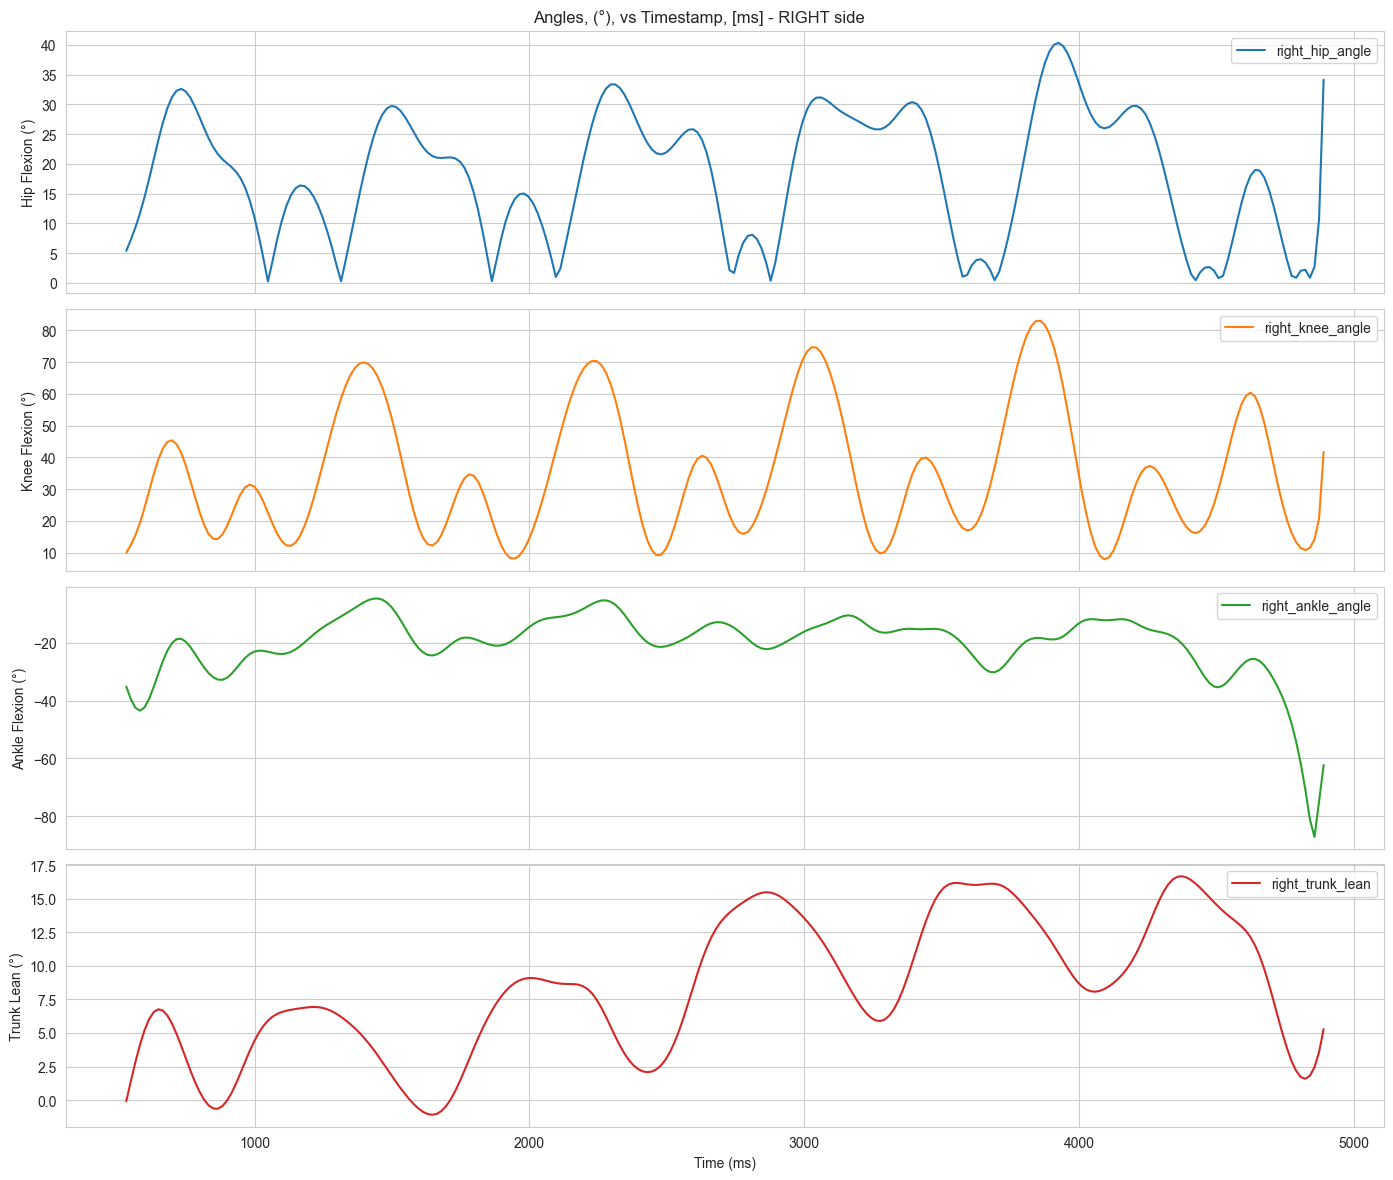

In [14]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)

right_angles.plot(
    x="timestamp_ms", y="right_hip_angle", ax=axes[0], color="tab:blue", grid=True
)
axes[0].set_ylabel("Hip Flexion (°)")

right_angles.plot(
    x="timestamp_ms", y="right_knee_angle", ax=axes[1], color="tab:orange", grid=True
)
axes[1].set_ylabel("Knee Flexion (°)")

right_angles.plot(
    x="timestamp_ms", y="right_ankle_angle", ax=axes[2], color="tab:green", grid=True
)
axes[2].set_ylabel("Ankle Flexion (°)")

right_angles.plot(
    x="timestamp_ms", y="right_trunk_lean", ax=axes[3], color="tab:red", grid=True
)
axes[3].set_ylabel("Trunk Lean (°)")
axes[3].set_xlabel("Time (ms)")

plt.suptitle("Angles, (°), vs Timestamp, [ms] - RIGHT side")
plt.tight_layout()
plt.show()

# 2. BIOMECHANICAL PARAMETERS

* **Ground contact time (GCT)**
  This metric calculates the duration a foot remains in contact with the ground during a single stride. The algorithm determines this by analyzing the horizontal (x-axis) positions of the heel and big toe relative to the hip. First, it accounts for the subject's overall running direction to ensure accurate relative positioning. It then identifies the frame of foot-strike (landing) using a peak-detection algorithm to find the maximum forward extension of the heel relative to the hip. To determine the liftoff frame, the algorithm searches forward from the landing point to locate the first instance where the big toe passes behind the hip (meaning its relative horizontal position becomes negative). The time elapsed between these two frames represents the GCT.

* **Flight time**
  This metric measures the aerial phase of the running gait cycle, representing the duration where neither foot is touching the ground. It is calculated by aggregating all computed landing and liftoff events from both the left and right feet into a single, chronologically sorted timeline. The algorithm iterates through this unified timeline and identifies an aerial phase whenever a liftoff event from one foot is immediately followed by a landing event from the contralateral (opposite) foot. The time difference between these two consecutive events constitutes the flight time.

In [15]:
left_gct = calculate_gct(smooth_data, fps=FPS, side="left")
right_gct = calculate_gct(smooth_data, fps=FPS, side="right")

In [16]:
true_landing_times = [1000 * t / FPS for t in [60, 106, 154]]
true_liftoff_times = [1000 * t / FPS for t in [76, 119, 165]]

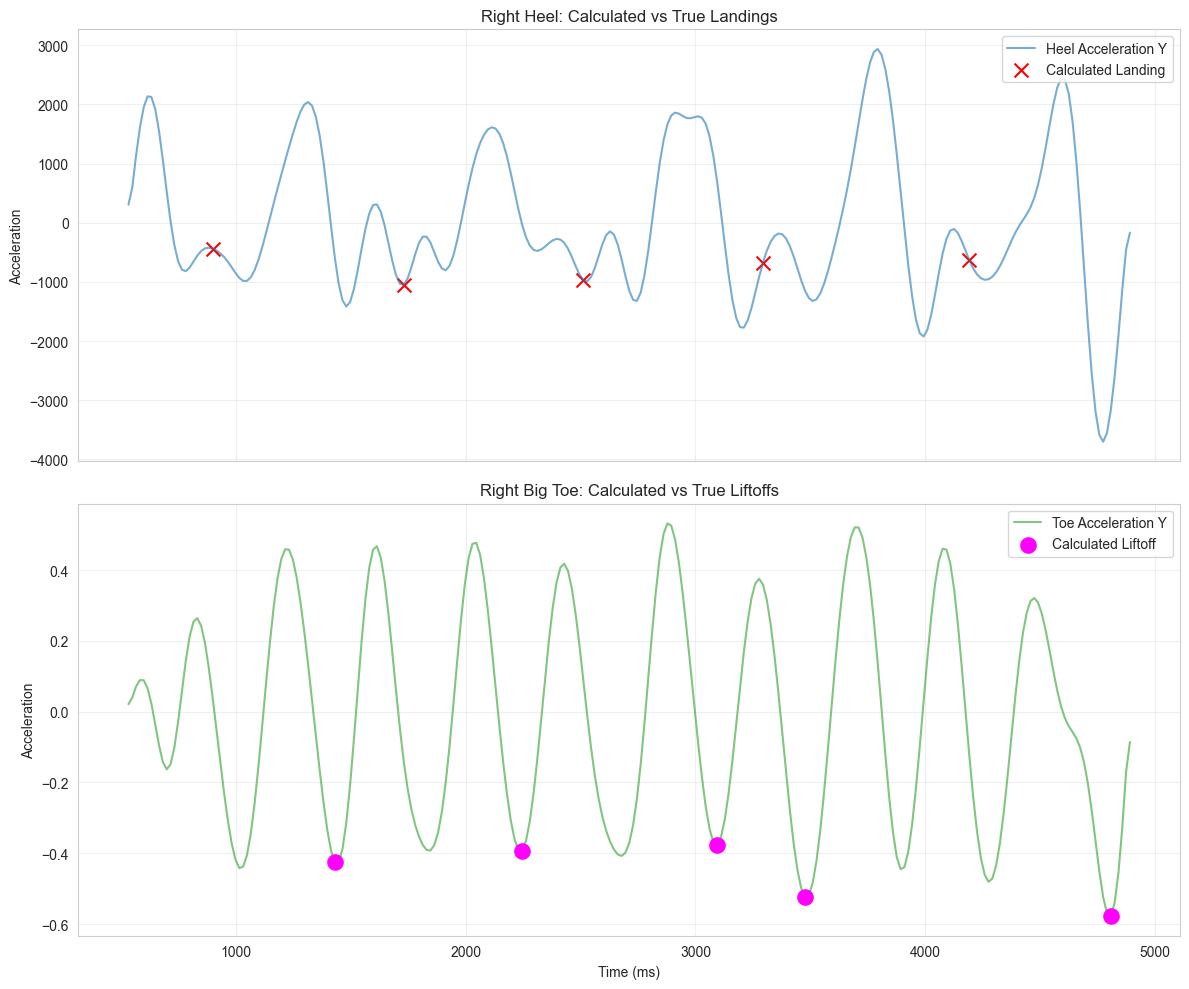

In [17]:
side = "right"

if side == "left":
    gct_records = left_gct
else:
    gct_records = right_gct

smooth_data[f"{side}_heel_rel_x"] = (
    smooth_data[f"{side}_heel_x"] - smooth_data[f"{side}_hip_x"]
)
smooth_data[f"{side}_toe_rel_x"] = (
    smooth_data[f"{side}_big_toe_x"] - smooth_data[f"{side}_hip_x"]
)

direction = (
    1
    if smooth_data[f"{side}_hip_x"].iloc[-1] > smooth_data[f"{side}_hip_x"].iloc[0]
    else -1
)

smooth_data[f"{side}_heel_rel_x"] *= direction
smooth_data[f"{side}_toe_rel_x"] *= direction

landings = gct_records["landing_time"]
liftoffs = gct_records["liftoff_time"]

landing_points = smooth_data[smooth_data["timestamp_ms"].isin(landings)]
liftoff_points = smooth_data[smooth_data["timestamp_ms"].isin(liftoffs)]


true_landing_points = smooth_data[
    smooth_data["timestamp_ms"].isin(
        [
            smooth_data["timestamp_ms"]
            .iloc[(smooth_data["timestamp_ms"] - t).abs().argsort()[:1]]
            .values[0]
            for t in true_landing_times
        ]
    )
]
#
# true_liftoff_points = smooth_data[smooth_data["timestamp_ms"].isin(
#     [smooth_data["timestamp_ms"].iloc[(smooth_data["timestamp_ms"] - t).abs().argsort()[:1]].values[0]
#      for t in true_liftoff_times]
# )]

# --- EXISTING PLOT CODE ---
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# AX1: Heel Plot
ax1.plot(
    smooth_data["timestamp_ms"],
    np.gradient(np.gradient(smooth_data[f"{side}_heel_y"], 1/FPS), 1/FPS),
    label="Heel Acceleration Y",
    color="tab:blue",
    alpha=0.6,
)

# # Your calculated landings
ax1.scatter(
    landing_points["timestamp_ms"],
    np.gradient(np.gradient(smooth_data[f"{side}_heel_y"], 1/FPS), 1/FPS)[
        smooth_data["timestamp_ms"].isin(landing_points["timestamp_ms"])
    ],
    color="red",
    marker="x",
    s=100,
    label="Calculated Landing",
)

# # Plot True Landings
# ax1.scatter(true_landing_points["timestamp_ms"], np.gradient(smooth_data[f"{side}_heel_y"])[smooth_data["timestamp_ms"].isin(true_landing_points["timestamp_ms"])],
#             color="black", marker="v", s=120, label="TRUE Landing (Manual)", zorder=6)

ax1.set_ylabel("Acceleration")
ax1.set_title(f"{side.capitalize()} Heel: Calculated vs True Landings")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)

# AX2: Toe Plot
ax2.plot(
    smooth_data["timestamp_ms"],
    (
        np.gradient(np.gradient(smooth_data[f"{side}_big_toe_y"]))
    ),  # smooth_data[f"{side}_toe_rel_x"],
    label="Toe Acceleration Y",
    color="tab:green",
    alpha=0.6,
)

# ax2.scatter(liftoff_points["timestamp_ms"], liftoff_points[f"{side}_toe_rel_x"],
#             color="magenta", marker="o", s=100, label="Calculated Liftoff")


# ax2.scatter(true_liftoff_points["timestamp_ms"], (np.gradient(smooth_data[f"{side}_big_toe_y"]))[smooth_data["timestamp_ms"].isin(true_liftoff_points["timestamp_ms"])],
#             color="black", marker="^", s=120, label="TRUE Liftoff (Manual)", zorder=6)

ax2.scatter(
    liftoff_points["timestamp_ms"],
    (np.gradient(np.gradient(smooth_data[f"{side}_big_toe_y"])))[
        smooth_data["timestamp_ms"].isin(liftoff_points["timestamp_ms"])
    ],
    color="magenta",
    marker="o",
    s=120,
    label="Calculated Liftoff",
    zorder=6,
)

ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Acceleration")
ax2.set_title(f"{side.capitalize()} Big Toe: Calculated vs True Liftoffs")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 Left side is marked blue, right -- red.

Gait phase visualization saved to: ../data/output/plots/landings/landing.png


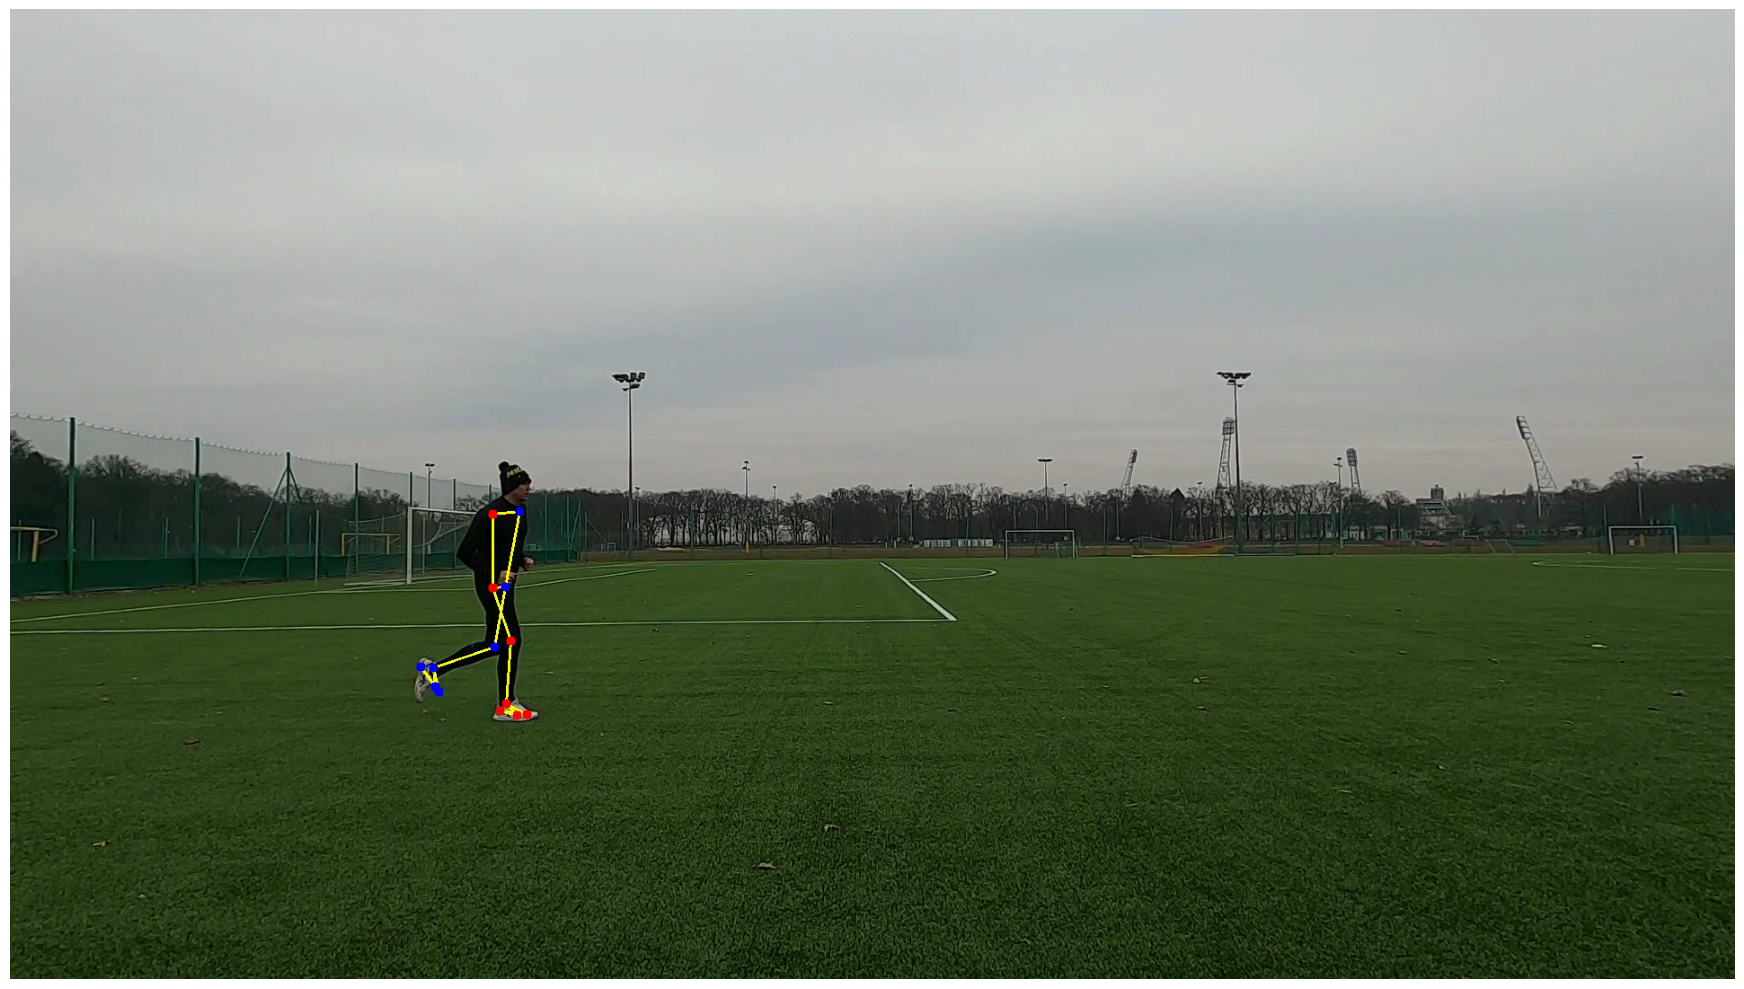

In [36]:
landing_idx = 1
landing_time = right_gct["landing_time"][landing_idx]
target_frame_idx = int(round((landing_time / 1000.0) * FPS))

visualize_gait_phase(
    overlay_path,
    target_frame_idx,
    landing_time,
    0,
    figsize=(25, 10),
    gait_phase=f"LANDING - {side.upper()}",
    save='../data/output/plots/landings/landing.png',
)

In [19]:
left_gct

,landing_time,liftoff_time,gct_ms,ic_accel,to_vel_y
0,1297.523203,1913.014979,615.491776,2935.359469,27.427789
1,2129.268846,2744.760622,615.491776,1453.819673,24.060262
2,2911.109750,3376.887310,465.777560,2324.401724,-5.688505
3,3826.029957,4374.982082,548.952124,1312.263544,45.569169
4,4607.870862,4824.124729,216.253867,3349.593113,-146.096535


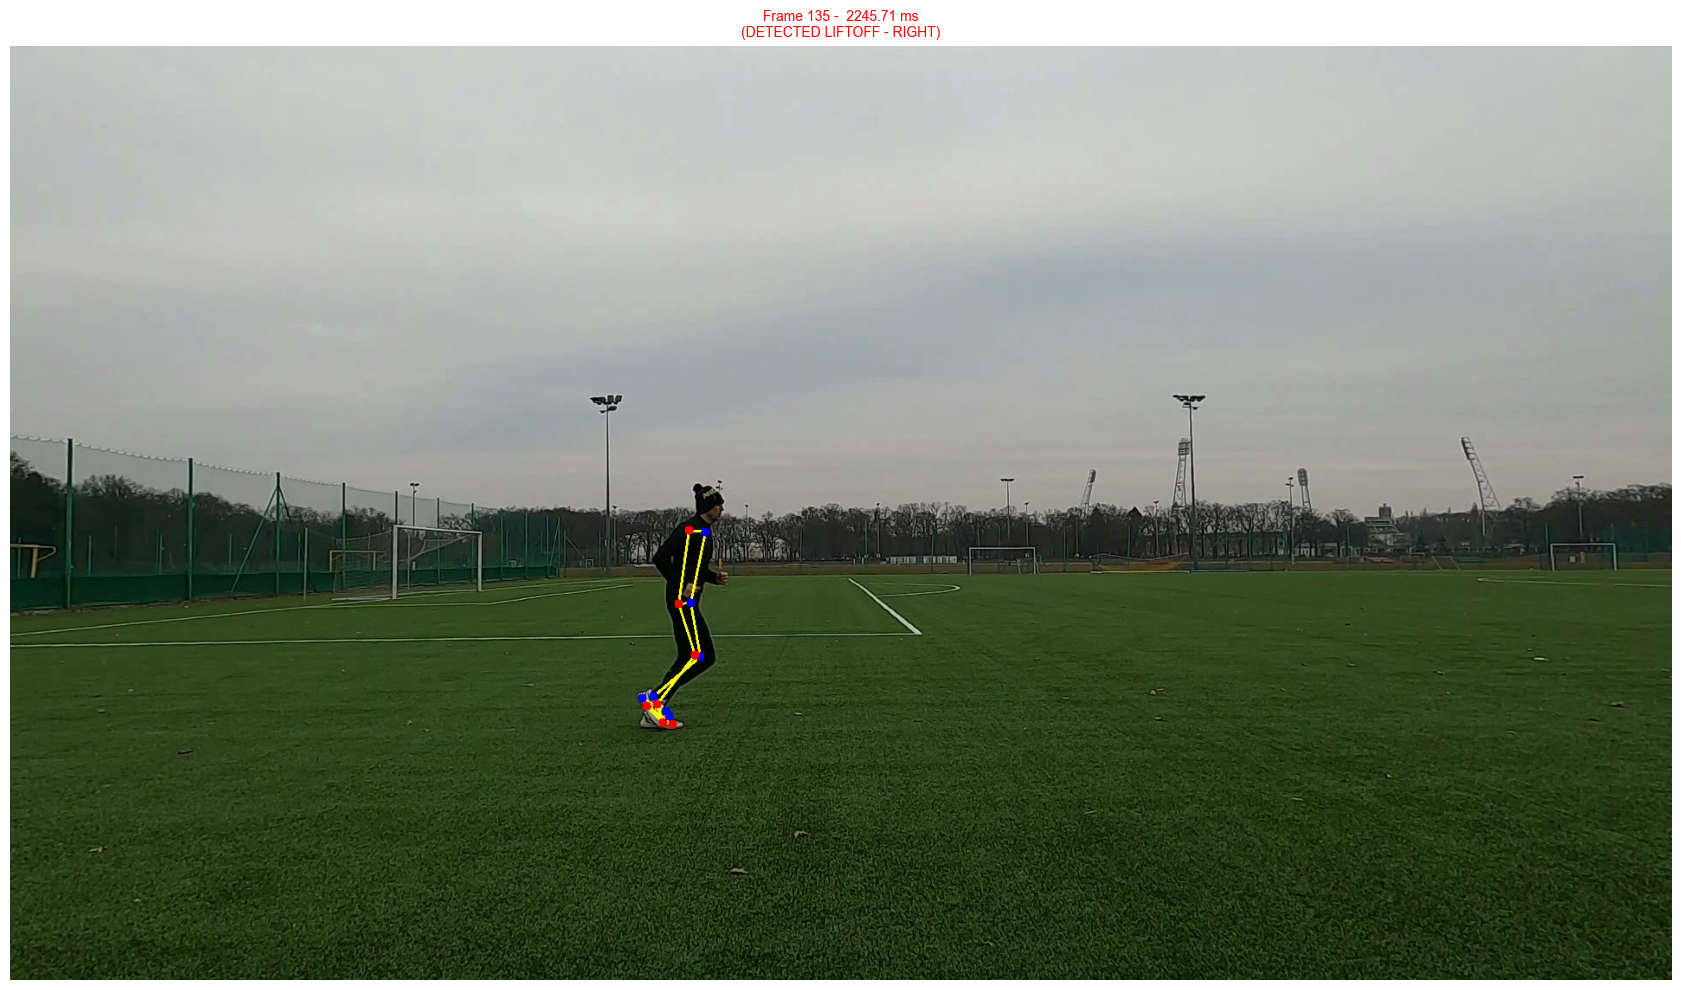

In [20]:
landing_idx = 1
landing_time = right_gct["liftoff_time"][landing_idx]
target_frame_idx = int(round((landing_time / 1000.0) * FPS))

visualize_gait_phase(
    overlay_path,
    target_frame_idx,
    landing_time,
    0,
    figsize=(25, 10),
    gait_phase=f"LIFTOFF - {side.upper()}",
    #save='../data/output/plots/landings/liftoff.png',
)

In [21]:
left_gct#.mean()  # TODO sprawdzic takie same wartosci tu

,landing_time,liftoff_time,gct_ms,ic_accel,to_vel_y
0,1297.523203,1913.014979,615.491776,2935.359469,27.427789
1,2129.268846,2744.760622,615.491776,1453.819673,24.060262
2,2911.109750,3376.887310,465.777560,2324.401724,-5.688505
3,3826.029957,4374.982082,548.952124,1312.263544,45.569169
4,4607.870862,4824.124729,216.253867,3349.593113,-146.096535


In [22]:
right_gct

,landing_time,liftoff_time,gct_ms,ic_accel,to_vel_y
0,898.285294,1430.602506,532.317211,3212.629772,7.107700
1,1730.030937,2245.713236,515.682299,1330.677381,-12.238418
2,2511.871842,3094.093792,582.221950,3849.391529,14.471183
3,3293.712746,3476.696787,182.984041,7503.598505,-23.266038
4,4191.998040,4807.489816,615.491776,1002.790949,-151.230288


In [23]:
print('mean ground contact time', np.array([*left_gct.gct_ms, *right_gct.gct_ms]).mean())

mean ground contact time 489.0664380392478


In [24]:
calculate_flight_times(left_gct, right_gct)

,takeoff_side,landing_side,liftoff_time,landing_time,flight_time_ms
0,right,left,1430.602506,1297.523203,-133.079303
1,left,right,1913.014979,1730.030937,-182.984041
2,right,left,2245.713236,2129.268846,-116.444390
3,left,right,2744.760622,2511.871842,-232.888780
4,right,left,3094.093792,2911.109750,-182.984041
5,left,right,3376.887310,3293.712746,-83.174564
6,right,left,3476.696787,3826.029957,349.333170
7,left,right,4374.982082,4191.998040,-182.984041
8,right,left,4807.489816,4607.870862,-199.618954


In [25]:
print('mean flight time', calculate_flight_times(left_gct, right_gct)['flight_time_ms'].mean())

mean flight time -107.2027717546348


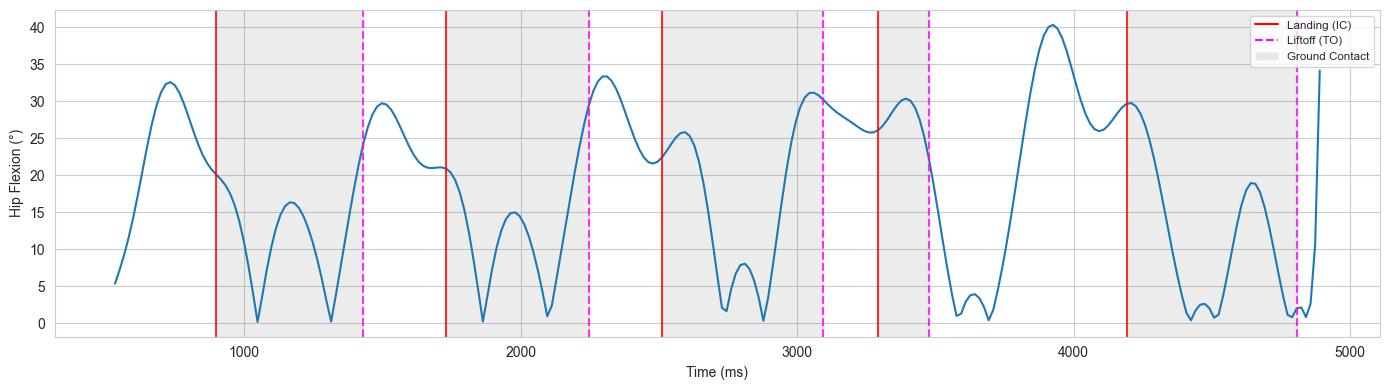

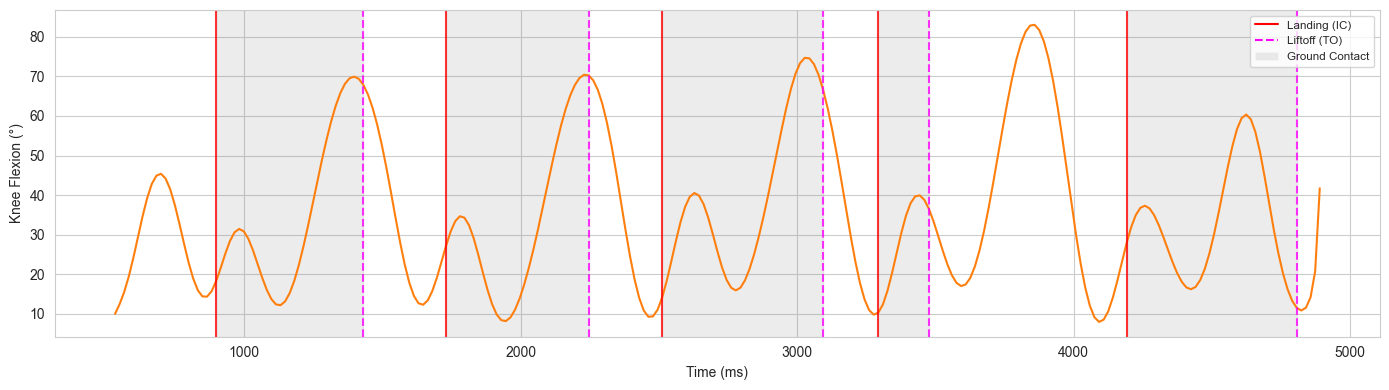

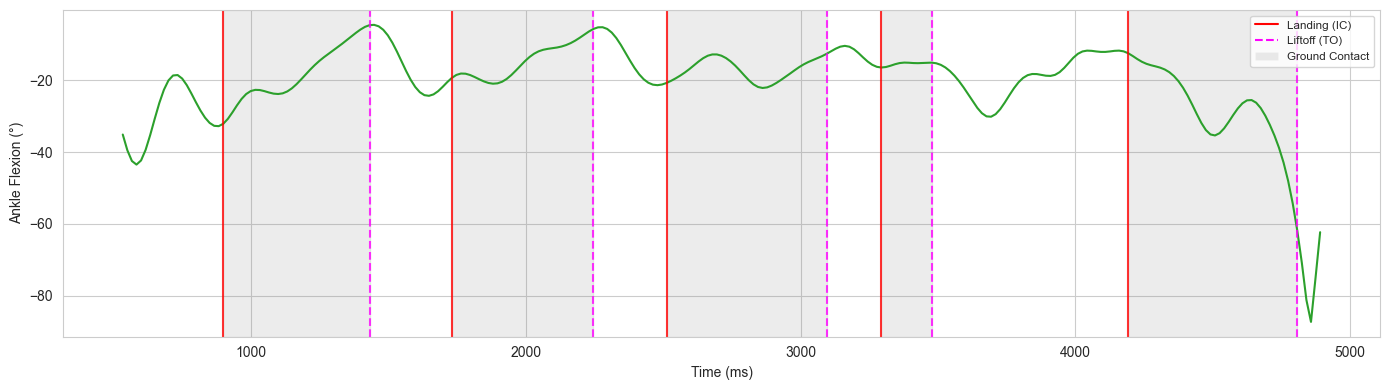

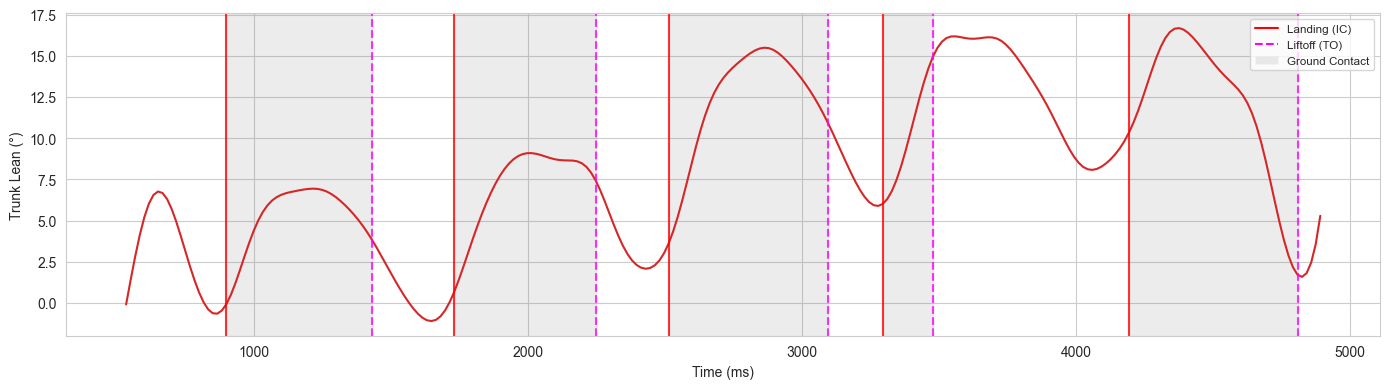

In [26]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Configuration for the individual plots
plots_config = [
    {"column": "right_hip_angle", "label": "Hip Flexion (°)", "color": "tab:blue", "filename": "right_hip_flexion.png"},
    {"column": "right_knee_angle", "label": "Knee Flexion (°)", "color": "tab:orange", "filename": "right_knee_flexion.png"},
    {"column": "right_ankle_angle", "label": "Ankle Flexion (°)", "color": "tab:green", "filename": "right_ankle_flexion.png"},
    {"column": "right_trunk_lean", "label": "Trunk Lean (°)", "color": "tab:red", "filename": "right_trunk_lean.png"}
]

# Define event line styles for accessibility and clarity
# IC: Solid Red, TO: Dashed Magenta
ic_style = {"color": "red", "linestyle": "-", "linewidth": 1.5, "label": "Landing (IC)"}
to_style = {"color": "magenta", "linestyle": "--", "linewidth": 1.5, "label": "Liftoff (TO)"}

for config in plots_config:
    fig, ax = plt.subplots(figsize=(14, 4))

    # Plot the kinematic data
    right_angles.plot(
        x="timestamp_ms",
        y=config["column"],
        ax=ax,
        color=config["color"],
        grid=True,
        legend=False
    )

    # Mark gait events (Stance Phases)
    for _, row in right_gct.iterrows():
        land_t = row["landing_time"]
        lift_t = row["liftoff_time"]

        # Vertical lines for events with different styles
        ax.axvline(x=land_t, **ic_style, alpha=0.8)
        ax.axvline(x=lift_t, **to_style, alpha=0.8)

        # Shaded area for Ground Contact (Stance Phase)
        ax.axvspan(land_t, lift_t, color="gray", alpha=0.15)

    # Formatting
    ax.set_ylabel(config["label"])
    ax.set_xlabel("Time (ms)")

    # Custom Legend for the individual plot
    landing_line = mlines.Line2D([], [], **ic_style)
    liftoff_line = mlines.Line2D([], [], **to_style)
    stance_patch = plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.15, label="Ground Contact")

    ax.legend(
        handles=[landing_line, liftoff_line, stance_patch],
        loc="upper right",
        fontsize='small'
    )

    # Save and close
    plt.tight_layout()
    plt.savefig(config["filename"], dpi=300)
    plt.show()
    plt.close(fig)


| RLA Phase | Hip Kinematics & Muscles | Knee Kinematics & Muscles | Ankle Kinematics & Muscles |
| :--- | :--- | :--- | :--- |
| **Initial Contact** | ~20° Flexion <br> *(Gluteus Maximus, Hamstrings)* | ~0-5° Flexion <br> *(Quadriceps)* | ~0° (Neutral) <br> *(Tibialis Anterior)* |
| **Loading Response** | ~20° Flexion <br> *(Gluteus Maximus, Hamstrings)* | ~15° Flexion <br> *(Quadriceps eccentric)* | ~5-10° Plantarflexion <br> *(Tibialis Anterior eccentric)* |
| **Midstance** | Moving to 0° (Neutral) <br> *(Iliopsoas eccentric)* | ~0-5° Flexion <br> *(Quadriceps)* | ~5° Dorsiflexion <br> *(Calf muscles eccentric)* |
| **Terminal Stance** | ~10-20° Extension <br> *(None/Passive)* | ~0-5° Flexion <br> *(None/Passive)* | ~10° Dorsiflexion <br> *(Calf muscles concentric)* |
| **Pre-Swing** | ~10° Extension <br> *(Adductor Longus)* | ~40° Flexion <br> *(Popliteus, passive flexion)* | ~15-20° Plantarflexion <br> *(Calf muscles)* |
| **Initial Swing** | ~15° Flexion <br> *(Iliopsoas)* | ~60° Flexion <br> *(Hamstrings)* | ~5-10° Plantarflexion <br> *(Tibialis Anterior)* |
| **Midswing** | ~25° Flexion <br> *(Hamstrings eccentric)* | ~25° Flexion <br> *(Hamstrings eccentric)* | ~0° (Neutral) <br> *(Tibialis Anterior)* |
| **Terminal Swing** | ~20° Flexion <br> *(Hamstrings eccentric)* | ~0-5° Flexion <br> *(Quadriceps)* | ~0° (Neutral) <br> *(Tibialis Anterior)* ||


source: https://www.physio-pedia.com/The_Gait_Cycle

# 3. KINEMATIC PARAMETERS - STEP METRICS

* **Step frequency**
  (cadence) evaluates the rate of stepping in steps per minute (SPM). It is determined by first constructing a unified, chronological timeline of all foot landing events. The step time is calculated as the duration (in milliseconds) between these two consecutive landings. Finally, step frequency is derived by dividing 60,000 by this step time.

* **Step length**
  This metric measures the spatial distance of a single step at the precise moment of foot-strike. It is calculated using two distinct methods: measuring the absolute horizontal distance (in pixels) between the left and right heels, and separately between the left and right big toes. To translate these pixel measurements into real-world meters, a dynamic scaling ratio is applied. This ratio is established by dividing the runner's known physical height by the vertical pixel height of the runner's bounding box (`bbox_h`) in that specific frame. Both the heel-to-heel and toe-to-toe metrics are recorded.

* **Running speed**
  This evaluates the subject's velocity for each individual step. It is calculated directly from the two preceding metrics by dividing the step length (heel version, in meters) by the step time (converted to seconds), resulting in a base speed of meters per second (m/s). This base speed is also converted into kilometers per hour (km/h) and a standard running pace (minutes per kilometer).

In [27]:
height = 1.85

In [28]:
step_metrics = calculate_step_metrics(
    left_gct, right_gct, smooth_data, runner_height_m=height
)

step_metrics

,landing_time,landing_foot,step_time_ms,cadence_spm,step_length_heel_px,step_length_toe_px,step_length_heel_m,step_length_toe_m,speed_m_s,speed_km_h,pace_min_km,speed_px_s,pace_s_100px
0,898.285294,right,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1297.523203,left,399.237909,150.286330,197.328486,201.244671,1.053674,1.074585,2.639213,9.501167,6.315013,494.262899,0.202321
2,1730.030937,right,432.507734,138.725843,191.473059,191.361681,1.016327,1.015736,2.349847,8.459447,7.092662,442.704357,0.225884
3,2129.268846,left,399.237909,150.286330,179.827834,180.502809,0.957368,0.960962,2.397989,8.632761,6.950268,450.427753,0.222011
4,2511.871842,right,382.602996,156.820518,209.431476,210.295770,1.099115,1.103651,2.872731,10.341832,5.801680,547.385877,0.182686
5,2911.109750,left,399.237909,150.286330,173.352573,164.867783,0.920030,0.874999,2.304466,8.296079,7.232332,434.208699,0.230304
6,3293.712746,right,382.602996,156.820518,211.127407,220.057230,1.114160,1.161285,2.912054,10.483393,5.723338,551.818489,0.181219
7,3826.029957,left,532.317211,112.714747,205.580256,198.798582,1.138404,1.100850,2.138581,7.698893,7.793328,386.198776,0.258934
8,4191.998040,right,365.968083,163.948723,176.352516,175.843281,0.955766,0.953006,2.611610,9.401795,6.381760,481.879497,0.207521
9,4607.870862,left,415.872821,144.274877,188.590051,184.199495,1.030164,1.006181,2.477113,8.917609,6.728261,453.480106,0.220517


In [29]:
#step_metrics[['step_length_heel_px', 'cadence']].mean()
step_metrics.drop(columns=["landing_time", "landing_foot"]).mean()

step_time_ms           412.176174
cadence_spm            147.129357
step_length_heel_px    192.562629
step_length_toe_px     191.907923
step_length_heel_m       1.031668
step_length_toe_m        1.027917
speed_m_s                2.522623
speed_km_h               9.081442
pace_min_km              6.668738
speed_px_s             471.374051
pace_s_100px             0.214600
dtype: float64

In [30]:
from src.gait_analysis.parameter_calculation.kinematic_parameters.step_parameters import (
    _create_step_timeline,
    calculate_cadence,
)

timeline_df = _create_step_timeline(left_gct, right_gct)

cadence = calculate_cadence(timeline_df)

In [31]:
import pandas as pd

merged = pd.merge(
    cadence, smooth_data, left_on="landing_time", right_on="timestamp_ms", how="inner"
)

In [32]:
merged

,landing_time,landing_foot,prev_foot,prev_time,step_time_ms,cadence_spm,timestamp_ms,track_id,bbox_area,bbox_x1,...,right_big_toe_y,right_big_toe_conf,right_small_toe_x,right_small_toe_y,right_small_toe_conf,right_heel_x,right_heel_y,right_heel_conf,right_heel_rel_x,right_toe_rel_x
0,898.285294,right,NaN,NaN,NaN,NaN,898.285294,1,45378.363281,122.940071,...,787.611036,0.817113,167.341953,789.784735,0.827361,151.894323,782.134229,0.868636,16.812828,43.809108
1,1297.523203,left,right,898.285294,399.237909,150.286330,1297.523203,1,49722.019531,311.571777,...,775.108530,0.858481,245.995768,770.216212,0.862186,238.030557,745.205403,0.864937,-89.410704,-70.067460
2,1730.030937,right,left,1297.523203,432.507734,138.725843,1730.030937,1,42527.765625,519.741821,...,783.676864,0.816156,560.695348,785.704622,0.833820,540.673702,778.886375,0.883978,5.563235,36.362914
3,2129.268846,left,right,1730.030937,399.237909,150.286330,2129.268846,1,44222.742188,707.399902,...,774.943813,0.834379,670.938673,770.822451,0.840967,655.913130,745.451293,0.855353,-69.950301,-45.435672
4,2511.871842,right,left,2129.268846,382.602996,156.820518,2511.871842,1,50055.171875,893.642700,...,775.969272,0.813098,953.717762,779.344558,0.830234,929.905888,776.382677,0.888456,20.121566,52.411584
5,2911.109750,left,right,2511.871842,399.237909,150.286330,2911.109750,1,50988.261719,1082.702026,...,759.277484,0.855922,1044.498327,755.675022,0.859264,1032.207512,731.501796,0.884929,-66.525003,-48.443903
6,3293.712746,right,left,2911.109750,382.602996,156.820518,3293.712746,1,52612.003906,1267.749878,...,766.822625,0.810051,1341.707596,771.413034,0.828133,1314.125153,772.589446,0.896176,28.912804,61.763847
7,3826.029957,left,right,3293.712746,532.317211,112.714747,3826.029957,1,32397.880859,1511.040283,...,761.164754,0.812789,1476.474519,754.841377,0.816052,1465.615013,722.664227,0.862476,-60.392209,-46.034883
8,4191.998040,right,left,3826.029957,365.968083,163.948723,4191.998040,1,46265.316406,1664.490356,...,767.727806,0.791522,1718.269695,769.870384,0.812534,1695.919046,768.561523,0.891867,2.579653,28.064524
9,4607.870862,left,right,4191.998040,415.872821,144.274877,4607.870862,1,36090.339844,1856.062134,...,759.923701,0.824746,1825.229599,756.410243,0.829541,1812.015901,733.166140,0.878314,-62.920805,-48.176910
